# Formula 1 Performance Analytics

**Project topic:** Formula 1 Performance Analytics: Measuring the Impact of Starting Position, Constructors and Circuits on Race Outcomes.

## 1. Abstract / Annotation

This project analyzes historical Formula 1 race performance using a relational dataset with race results, races, drivers, constructors, circuits and race status information. The main goal is to understand how starting grid position, constructors, historical eras and race reliability are related to final race outcomes.

The analysis includes data loading, data quality checks, cleanup of hidden missing values, table merging, feature engineering, descriptive statistics, visual exploration and hypothesis checking. Contribution note: both team members worked on dataset preparation, feature engineering, visualizations and interpretation; this note can be adjusted before submission if needed.

## 2. Imports

We start by importing the libraries used for data analysis and visualization.

In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 3. Data loading

The project uses multiple CSV files from the Formula 1 dataset. The notebook is located in the `notebooks` folder, while the raw data is expected to be in `data/raw`.

In [8]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(RAW_DATA_DIR.glob("*.csv"))

tables = {}

for path in csv_files:
    table_name = path.stem.replace("cleaned_", "")
    tables[table_name] = pd.read_csv(path)

print("Loaded tables:")
for name, table in tables.items():
    print(f"{name}: {table.shape[0]} rows, {table.shape[1]} columns")

Loaded tables:
circuits: 78 rows, 9 columns
constructor_results: 12909 rows, 5 columns
constructor_standings: 13675 rows, 7 columns
constructors: 214 rows, 5 columns
driver_standings: 35449 rows, 7 columns
drivers: 865 rows, 9 columns
lap_times: 869870 rows, 6 columns
pit_stops: 22215 rows, 7 columns
qualifying: 11058 rows, 9 columns
races: 1171 rows, 18 columns
results: 27326 rows, 18 columns
seasons: 77 rows, 2 columns
sprint_results: 524 rows, 17 columns
status: 140 rows, 2 columns


## 4. Dataset description

The dataset is a composite relational dataset. Instead of using only one table, this project combines several tables through common IDs. The main analytical table is based on race results, enriched with race metadata, driver information, constructor information, circuit information and finishing status.

In [9]:
required_tables = ["results", "races", "drivers", "constructors", "circuits", "status"]
missing_tables = [name for name in required_tables if name not in tables]

table_summary = pd.DataFrame(
    {
        "table": list(tables.keys()),
        "rows": [df.shape[0] for df in tables.values()],
        "columns": [df.shape[1] for df in tables.values()],
    }
).sort_values("table")

table_summary

,table,rows,columns
0,circuits,78,9
1,constructor_results,12909,5
2,constructor_standings,13675,7
3,constructors,214,5
4,driver_standings,35449,7
5,drivers,865,9
6,lap_times,869870,6
7,pit_stops,22215,7
8,qualifying,11058,9
9,races,1171,18


In [10]:
tables["results"].head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.3,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


## 5. Data quality check

Although the dataset is described as cleaned, it still contains hidden missing values encoded as `\N`. These values are not detected by `isna()` until they are explicitly converted into real missing values.

In [11]:
hidden_missing_summary = []

for name, table in tables.items():
    hidden_missing_count = (table.astype("string") == "\\N").sum().sum()
    hidden_missing_summary.append(
        {
            "table": name,
            "hidden_missing_values": hidden_missing_count,
        }
    )

hidden_missing_summary = pd.DataFrame(hidden_missing_summary).sort_values(
    "hidden_missing_values",
    ascending=False
)

hidden_missing_summary

,table,hidden_missing_values
10,results,123928
1,constructor_results,12892
8,qualifying,12112
9,races,11477
5,drivers,1559
12,sprint_results,490
4,driver_standings,13
7,pit_stops,6
2,constructor_standings,1
0,circuits,0


In [12]:
tables = {
    name: table.replace("\\N", pd.NA)
    for name, table in tables.items()
}

missing_after_replacement = []

for name, table in tables.items():
    missing_after_replacement.append(
        {
            "table": name,
            "missing_values_after_replacement": table.isna().sum().sum(),
        }
    )

pd.DataFrame(missing_after_replacement).sort_values(
    "missing_values_after_replacement",
    ascending=False
)

,table,missing_values_after_replacement
10,results,123928
1,constructor_results,12892
8,qualifying,12112
9,races,11477
5,drivers,1559
12,sprint_results,490
4,driver_standings,13
7,pit_stops,6
2,constructor_standings,1
0,circuits,0


## 6. Data cleanup and main table construction

The main table is constructed by selecting relevant columns, renaming columns with conflicting names, converting numerical fields and merging the relational tables. We avoid removing rows too early, because different hypotheses require different filters.

In [15]:
results = tables["results"][
    [
        "resultId",
        "raceId",
        "driverId",
        "constructorId",
        "grid",
        "positionOrder",
        "points",
        "laps",
        "statusId",
    ]
].copy()

races = tables["races"][
    [
        "raceId",
        "year",
        "round",
        "circuitId",
        "name",
        "date",
    ]
].rename(
    columns={
        "name": "race_name",
    }
).copy()

drivers = tables["drivers"][
    [
        "driverId",
        "forename",
        "surname",
        "dob",
        "nationality",
    ]
].rename(
    columns={
        "nationality": "driver_nationality",
    }
).copy()

constructors = tables["constructors"][
    [
        "constructorId",
        "name",
        "nationality",
    ]
].rename(
    columns={
        "name": "constructor_name",
        "nationality": "constructor_nationality",
    }
).copy()

circuits = tables["circuits"][
    [
        "circuitId",
        "name",
        "location",
        "country",
        "lat",
        "lng",
        "alt",
    ]
].rename(
    columns={
        "name": "circuit_name",
        "country": "circuit_country",
    }
).copy()

status = tables["status"][
    [
        "statusId",
        "status",
    ]
].copy()

In [17]:
results_numeric_columns = [
    "grid",
    "positionOrder",
    "points",
    "laps",
]

for column in results_numeric_columns:
    results[column] = pd.to_numeric(results[column], errors="coerce")

races_numeric_columns = [
    "year",
    "round",
]

for column in races_numeric_columns:
    races[column] = pd.to_numeric(races[column], errors="coerce")

In [18]:
main_df = (
    results
    .merge(races, on="raceId", how="left")
    .merge(drivers, on="driverId", how="left")
    .merge(constructors, on="constructorId", how="left")
    .merge(circuits, on="circuitId", how="left")
    .merge(status, on="statusId", how="left")
)

print("Main dataset shape:", main_df.shape)

key_columns = [
    "race_name",
    "driver_nationality",
    "constructor_name",
    "circuit_name",
    "status",
]

print("\nMissing values in key merged columns:")
print(main_df[key_columns].isna().sum())

print("\nMissing values in the main dataset:")
print(main_df.isna().sum().sort_values(ascending=False).head(10))

Main dataset shape: (27326, 27)

Missing values in key merged columns:
race_name             0
driver_nationality    0
constructor_name      0
circuit_name          0
status                0
dtype: int64

Missing values in the main dataset:
grid             20
raceId            0
resultId          0
driverId          0
constructorId     0
positionOrder     0
points            0
laps              0
statusId          0
year              0
dtype: int64


## 7. Data transformation

Several new variables are created for analysis. `position_gain` measures how many positions a driver gained or lost during a race. `is_podium`, `is_points_finish` and `is_classified_finish` are binary indicators. The variable `era` groups seasons into historical periods.

In [19]:
main_df["driver_name"] = main_df["forename"] + " " + main_df["surname"]

main_df["position_gain"] = main_df["grid"] - main_df["positionOrder"]

main_df["is_podium"] = main_df["positionOrder"] <= 3

main_df["is_points_finish"] = main_df["points"] > 0

main_df["is_classified_finish"] = (
    (main_df["status"] == "Finished") |
    (main_df["status"].str.contains("Lap", na=False))
)

max_year = int(main_df["year"].max())

era_bins = [1949, 1979, 1999, 2013, max_year]
era_labels = [
    "1950-1979",
    "1980-1999",
    "2000-2013",
    f"2014-{max_year}",
]

main_df["era"] = pd.cut(
    main_df["year"],
    bins=era_bins,
    labels=era_labels,
)

def assign_grid_group(grid):
    if pd.isna(grid):
        return pd.NA
    elif grid <= 5:
        return "Top 5"
    elif grid <= 10:
        return "P6-P10"
    elif grid <= 15:
        return "P11-P15"
    else:
        return "P16+"

main_df["grid_group"] = main_df["grid"].apply(assign_grid_group)

new_columns = [
    "driver_name",
    "position_gain",
    "is_podium",
    "is_points_finish",
    "is_classified_finish",
    "era",
    "grid_group",
]

main_df[new_columns].head()

,driver_name,position_gain,is_podium,is_points_finish,is_classified_finish,era,grid_group
0,Lewis Hamilton,0.0,True,True,True,2000-2013,Top 5
1,Nick Heidfeld,3.0,True,True,True,2000-2013,Top 5
2,Nico Rosberg,4.0,True,True,True,2000-2013,P6-P10
3,Fernando Alonso,7.0,False,True,True,2000-2013,P11-P15
4,Heikki Kovalainen,-2.0,False,True,True,2000-2013,Top 5


In [20]:
print("Missing values in new columns:")
print(main_df[new_columns].isna().sum())

print("\nEra distribution:")
print(main_df["era"].value_counts())

print("\nGrid group distribution:")
print(main_df["grid_group"].value_counts(dropna=False))

print("\nClassified finish distribution:")
print(main_df["is_classified_finish"].value_counts())

Missing values in new columns:
driver_name              0
position_gain           20
is_podium                0
is_points_finish         0
is_classified_finish     0
era                      0
grid_group              20
dtype: int64

Era distribution:
era
1980-1999    8753
1950-1979    7927
2000-2013    5453
2014-2026    5193
Name: count, dtype: int64

Grid group distribution:
grid_group
P16+       8340
Top 5      7428
P6-P10     5786
P11-P15    5752
NaN          20
Name: count, dtype: int64

Classified finish distribution:
is_classified_finish
True     15650
False    11676
Name: count, dtype: int64


In [21]:
output_path = PROCESSED_DATA_DIR / "f1_main_dataset.csv"
main_df.to_csv(output_path, index=False)

print(f"Saved processed dataset to: {output_path}")
print(f"Final dataset shape: {main_df.shape}")

Saved processed dataset to: C:\Users\1\PycharmProjects\formula-1-performance-analytics\data\processed\f1_main_dataset.csv
Final dataset shape: (27326, 34)


## 8. Descriptive statistics

The following table shows mean, median and standard deviation for selected numerical fields. These variables describe starting position, final position, race performance, season structure and position changes.

In [22]:
numeric_columns = [
    "grid",
    "positionOrder",
    "points",
    "laps",
    "year",
    "round",
    "position_gain",
]

descriptive_stats = main_df[numeric_columns].agg(["mean", "median", "std"]).T
descriptive_stats

,mean,median,std
grid,11.124954,11.0,7.178856
positionOrder,12.749323,12.0,7.639046
points,2.049881,0.0,4.447905
laps,46.457110,53.0,29.314217
year,1992.094891,1992.0,20.322882
round,8.561882,8.0,5.139342
position_gain,-1.626016,0.0,9.544239


## 9. Overview plots

This section provides a general visual overview of the data. The plots include a distribution plot, a scatter plot, a line plot and a correlation heatmap.

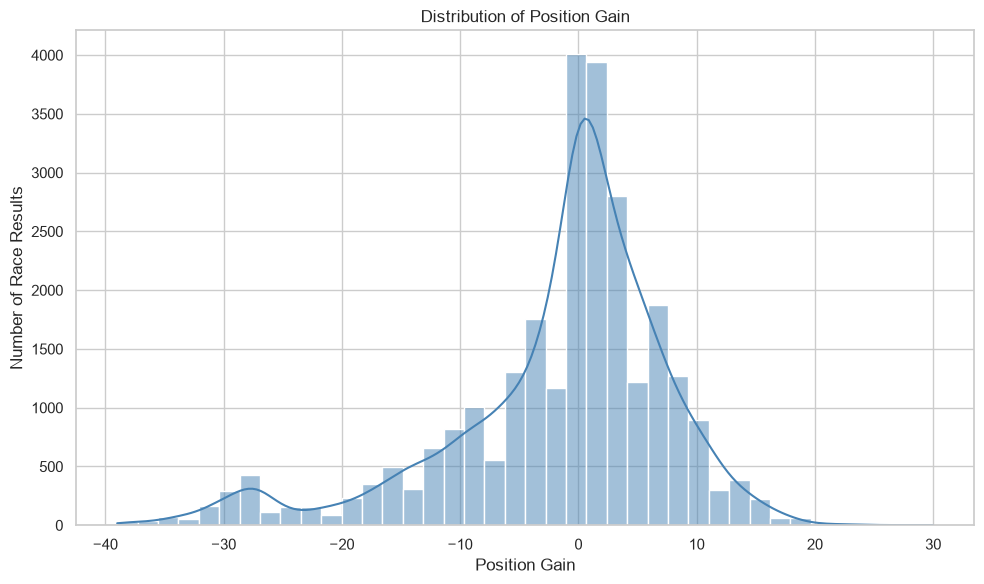

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(main_df["position_gain"].dropna(), bins=40, kde=True, color="steelblue")

plt.title("Distribution of Position Gain")
plt.xlabel("Position Gain")
plt.ylabel("Number of Race Results")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "position_gain_distribution.png", dpi=300)
plt.show()

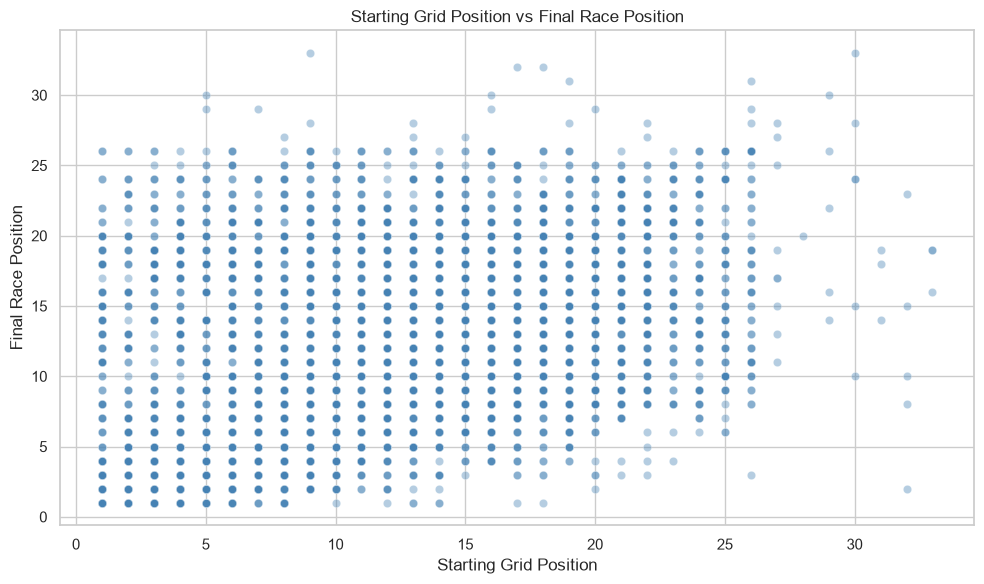

In [25]:
grid_df = main_df[
    (main_df["grid"].notna()) &
    (main_df["grid"] > 0) &
    (main_df["positionOrder"].notna()) &
    (main_df["positionOrder"] > 0)
].copy()

sample_df = grid_df.sample(min(5000, len(grid_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    color="steelblue",
    data=sample_df,
    x="grid",
    y="positionOrder",
    alpha=0.4,
)

plt.title("Starting Grid Position vs Final Race Position")
plt.xlabel("Starting Grid Position")
plt.ylabel("Final Race Position")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "grid_vs_final_position.png", dpi=300)
plt.show()

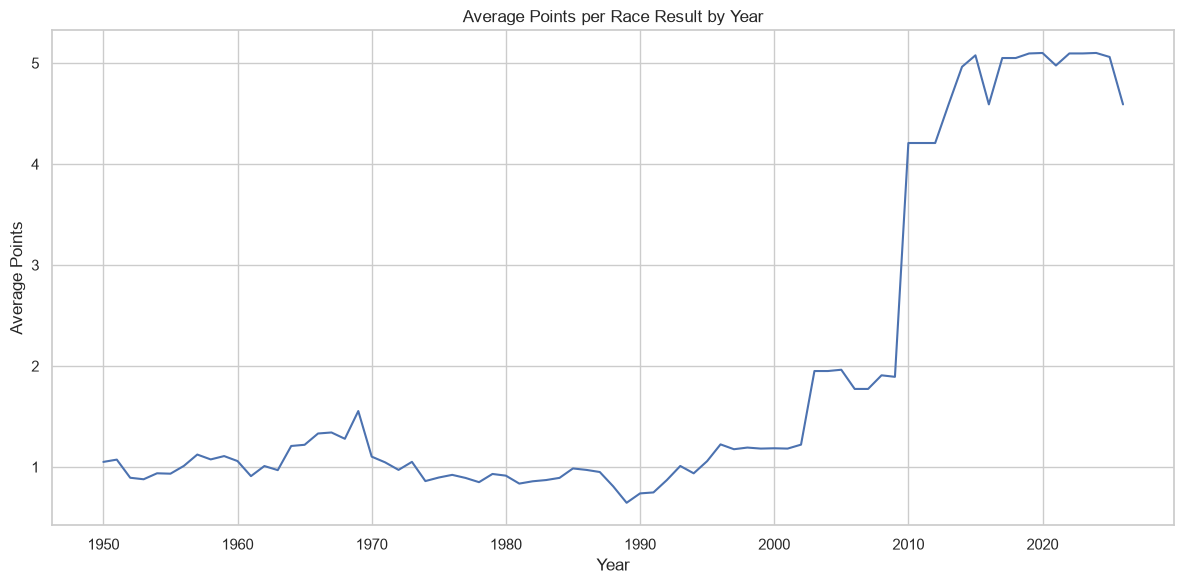

In [26]:
avg_points_by_year = (
    main_df
    .groupby("year")["points"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=avg_points_by_year,
    x="year",
    y="points",
)

plt.title("Average Points per Race Result by Year")
plt.xlabel("Year")
plt.ylabel("Average Points")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "average_points_by_year.png", dpi=300)
plt.show()

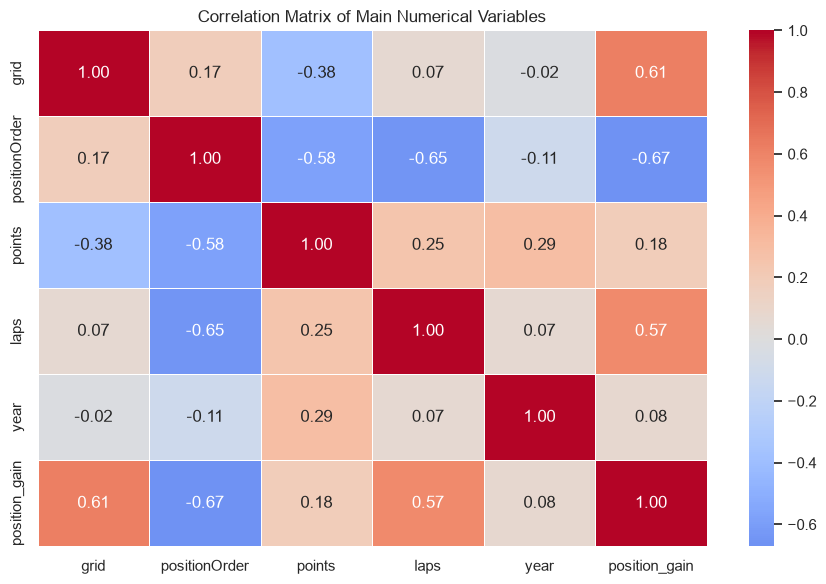

In [27]:
corr_columns = [
    "grid",
    "positionOrder",
    "points",
    "laps",
    "year",
    "position_gain",
]

plt.figure(figsize=(9, 6))
sns.heatmap(
    main_df[corr_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)

plt.title("Correlation Matrix of Main Numerical Variables")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=300)
plt.show()

The overview plots show that most drivers finish close to their starting positions, but there are also extreme gains and losses. The scatter plot suggests a positive relationship between starting and final position. The line plot of average points should be interpreted carefully, because the Formula 1 points system changed over time.

## 10. Detailed overview / comparisons

This section provides more detailed comparisons across eras, starting groups, constructors and circuits.

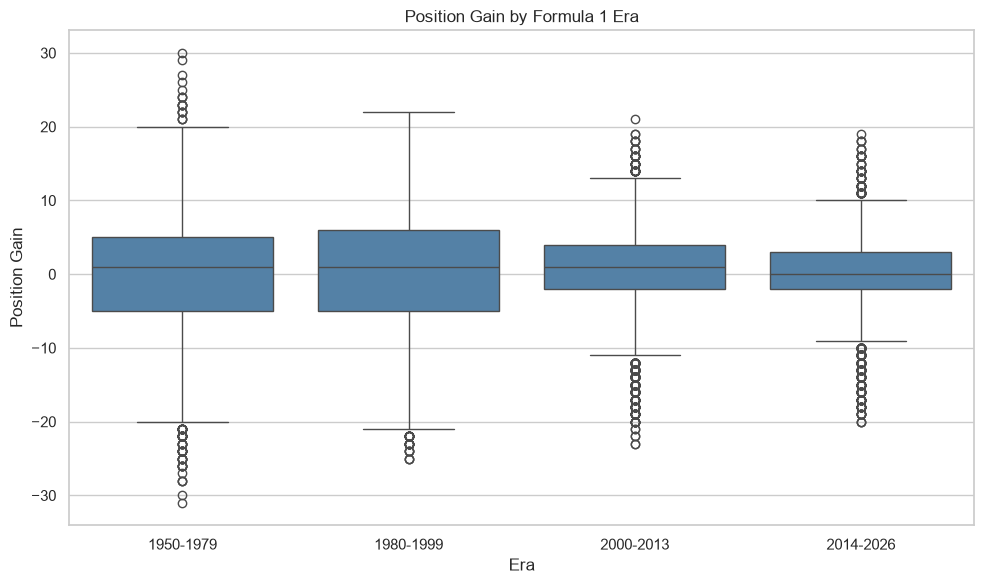

In [28]:
era_order = era_labels

plt.figure(figsize=(10, 6))
sns.boxplot(
    color="steelblue",
    data=grid_df,
    x="era",
    y="position_gain",
    order=era_order,
)

plt.title("Position Gain by Formula 1 Era")
plt.xlabel("Era")
plt.ylabel("Position Gain")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "position_gain_by_era.png", dpi=300)
plt.show()

In [32]:
grid_group_order = ["Top 5", "P6-P10", "P11-P15", "P16+"]

grid_group_summary = (
    grid_df
    .groupby("grid_group")
    .agg(
        race_results=("resultId", "count"),
        podium_rate=("is_podium", "mean"),
        points_finish_rate=("is_points_finish", "mean"),
        avg_points=("points", "mean"),
        avg_position_gain=("position_gain", "mean"),
    )
    .reset_index()
)

grid_group_summary["grid_group"] = pd.Categorical(
    grid_group_summary["grid_group"],
    categories=grid_group_order,
    ordered=True,
)

grid_group_summary = grid_group_summary.sort_values("grid_group")

grid_group_summary

,grid_group,race_results,podium_rate,points_finish_rate,avg_points,avg_position_gain
3,Top 5,5790,0.451468,0.663385,6.225891,-4.358549
2,P6-P10,5786,0.109056,0.455064,2.260543,-2.559454
0,P11-P15,5752,0.029555,0.232267,0.810675,0.250869
1,P16+,8340,0.007554,0.073861,0.248398,4.635132


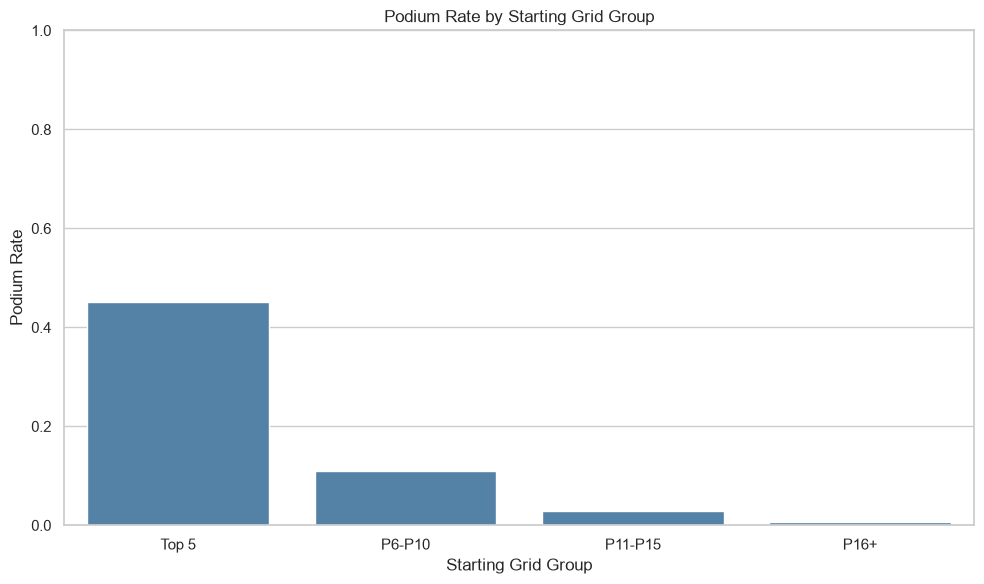

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(
    color="steelblue",
    data=grid_group_summary,
    x="grid_group",
    y="podium_rate",
    order=grid_group_order,
)

plt.title("Podium Rate by Starting Grid Group")
plt.xlabel("Starting Grid Group")
plt.ylabel("Podium Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "podium_rate_by_grid_group.png", dpi=300)
plt.show()

In [35]:
constructor_summary_all = (
    grid_df
    .groupby("constructor_name")
    .agg(
        race_results=("resultId", "count"),
        total_points=("points", "sum"),
        avg_points=("points", "mean"),
        podium_rate=("is_podium", "mean"),
        avg_position_gain=("position_gain", "mean"),
    )
    .reset_index()
)

constructor_summary_all = constructor_summary_all[
    constructor_summary_all["race_results"] >= 100
].copy()

top_constructors_by_points = (
    constructor_summary_all
    .sort_values("total_points", ascending=False)
    .head(10)
)

top_constructors_by_points

,constructor_name,race_results,total_points,avg_points,podium_rate,avg_position_gain
70,Ferrari,2471,11538.27,4.669474,0.344395,-1.818697
129,Mercedes,703,8294.64,11.798919,0.449502,-0.886202
155,Red Bull,831,8047.00,9.683514,0.356197,-0.647413
124,McLaren,1955,7838.50,4.009463,0.278261,-1.331458
197,Williams,1705,3755.00,2.202346,0.184751,-1.531965
156,Renault,782,1777.00,2.272379,0.131714,-1.882353
74,Force India,424,1098.00,2.589623,0.014151,0.334906
180,Team Lotus,822,995.00,1.210462,0.138686,-0.586375
22,Benetton,519,861.50,1.659923,0.196532,-1.472062
191,Tyrrell,846,711.00,0.840426,0.091017,1.767139


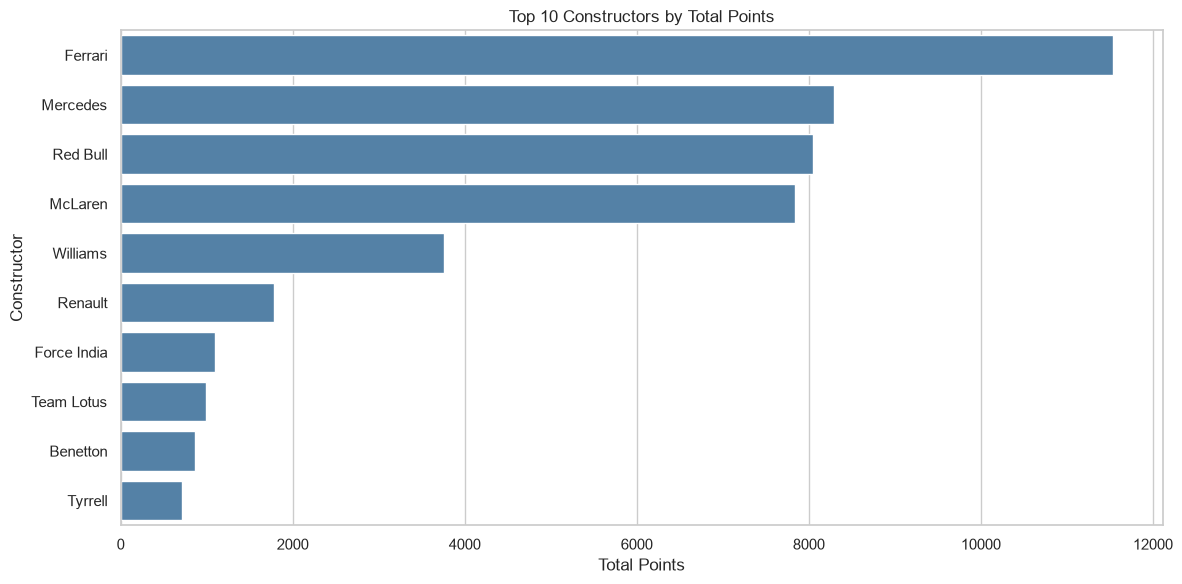

In [36]:
plt.figure(figsize=(12, 6))
sns.barplot(
    color="steelblue",
    data=top_constructors_by_points,
    x="total_points",
    y="constructor_name",
)

plt.title("Top 10 Constructors by Total Points")
plt.xlabel("Total Points")
plt.ylabel("Constructor")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_constructors_total_points.png", dpi=300)
plt.show()

In [38]:
circuit_summary = (
    grid_df
    .groupby("circuit_name")
    .agg(
        race_results=("resultId", "count"),
        avg_position_gain=("position_gain", "mean"),
        median_position_gain=("position_gain", "median"),
    )
    .reset_index()
)

top_circuit_gain = (
    circuit_summary[circuit_summary["race_results"] >= 100]
    .sort_values("avg_position_gain", ascending=False)
    .head(10)
)

top_circuit_gain

,circuit_name,race_results,avg_position_gain,median_position_gain
12,Autódromo Juan y Oscar Gálvez,435,0.271264,1.0
62,Reims-Gueux,242,0.074380,0.0
3,Aintree,126,0.055556,1.0
67,Sepang International Circuit,410,0.043902,1.0
51,Miami International Autodrome,100,0.040000,0.0
56,Nürburgring,939,0.029819,1.0
25,Circuit de Monaco,1457,0.028140,1.0
28,Circuit de Spa-Francorchamps,1208,0.027318,1.0
37,Hockenheimring,860,0.015116,0.0
13,Autódromo do Estoril,331,0.015106,1.0


## 11. Hypothesis checking

This section tests three hypotheses. Each hypothesis uses filtered data and comparison outputs that are appropriate for the question.

### Hypothesis 1

**Starting grid position is more strongly associated with final race position in modern Formula 1 than in earlier eras.**

Since grid position and final position are rank-like variables, Spearman correlation is used as the main measure of association.

In [40]:
correlation_rows = []

for era, group in grid_df.groupby("era"):
    pearson_corr = group["grid"].corr(group["positionOrder"])
    spearman_corr = group[["grid", "positionOrder"]].corr(method="spearman").iloc[0, 1]

    correlation_rows.append(
        {
            "era": era,
            "race_results": len(group),
            "pearson_correlation": pearson_corr,
            "spearman_correlation": spearman_corr,
            "avg_position_gain": group["position_gain"].mean(),
            "median_position_gain": group["position_gain"].median(),
        }
    )

era_correlation = pd.DataFrame(correlation_rows)

era_correlation["era"] = pd.Categorical(
    era_correlation["era"],
    categories=era_order,
    ordered=True,
)

era_correlation = era_correlation.sort_values("era")

era_correlation

,era,race_results,pearson_correlation,spearman_correlation,avg_position_gain,median_position_gain
0,1950-1979,7310,0.387330,0.388400,0.039261,1.0
1,1980-1999,7825,0.355268,0.358262,0.003323,1.0
2,2000-2013,5439,0.550985,0.555525,0.000368,1.0
3,2014-2026,5094,0.621854,0.626065,-0.051040,0.0


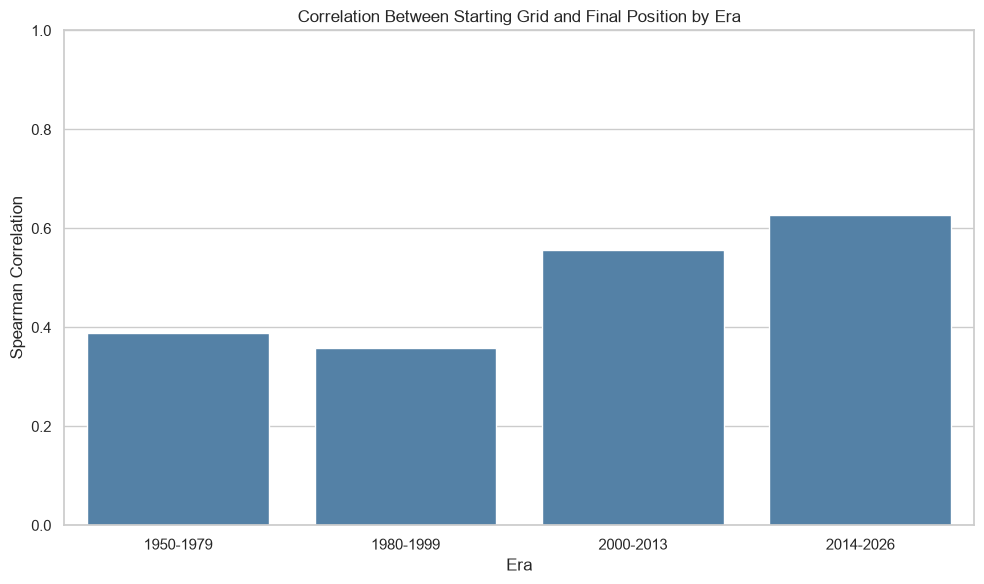

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(
    color="steelblue",
    data=era_correlation,
    x="era",
    y="spearman_correlation",
)

plt.title("Correlation Between Starting Grid and Final Position by Era")
plt.xlabel("Era")
plt.ylabel("Spearman Correlation")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "h1_grid_final_position_correlation_by_era.png", dpi=300)
plt.show()

The first hypothesis is mostly supported by the data. The correlation between starting grid position and final race position is higher in the modern eras than in the earlier periods. The strongest relationship is observed in the most recent era, which suggests that modern Formula 1 race outcomes are more strongly associated with starting position. However, the increase is not perfectly monotonic across all eras.

### Hypothesis 2

**Top constructors have higher average points and podium rates, but they do not necessarily have the highest average position gain.**

This hypothesis checks whether constructor success is visible across several metrics, not only total points.

In [42]:
constructor_df = grid_df[
    grid_df["constructor_name"].notna()
].copy()

constructor_summary = (
    constructor_df
    .groupby("constructor_name")
    .agg(
        race_results=("resultId", "count"),
        total_points=("points", "sum"),
        avg_points=("points", "mean"),
        podium_rate=("is_podium", "mean"),
        avg_position_gain=("position_gain", "mean"),
        median_position_gain=("position_gain", "median"),
    )
    .reset_index()
)

constructor_summary = constructor_summary[
    constructor_summary["race_results"] >= 100
].copy()

top_constructors = (
    constructor_summary
    .sort_values("total_points", ascending=False)
    .head(10)
    .copy()
)

top_constructors[
    [
        "constructor_name",
        "race_results",
        "total_points",
        "avg_points",
        "podium_rate",
        "avg_position_gain",
        "median_position_gain",
    ]
]

,constructor_name,race_results,total_points,avg_points,podium_rate,avg_position_gain,median_position_gain
70,Ferrari,2471,11538.27,4.669474,0.344395,-1.818697,0.0
129,Mercedes,703,8294.64,11.798919,0.449502,-0.886202,0.0
155,Red Bull,831,8047.00,9.683514,0.356197,-0.647413,0.0
124,McLaren,1955,7838.50,4.009463,0.278261,-1.331458,0.0
197,Williams,1705,3755.00,2.202346,0.184751,-1.531965,0.0
156,Renault,782,1777.00,2.272379,0.131714,-1.882353,0.0
74,Force India,424,1098.00,2.589623,0.014151,0.334906,1.0
180,Team Lotus,822,995.00,1.210462,0.138686,-0.586375,0.0
22,Benetton,519,861.50,1.659923,0.196532,-1.472062,1.0
191,Tyrrell,846,711.00,0.840426,0.091017,1.767139,2.0


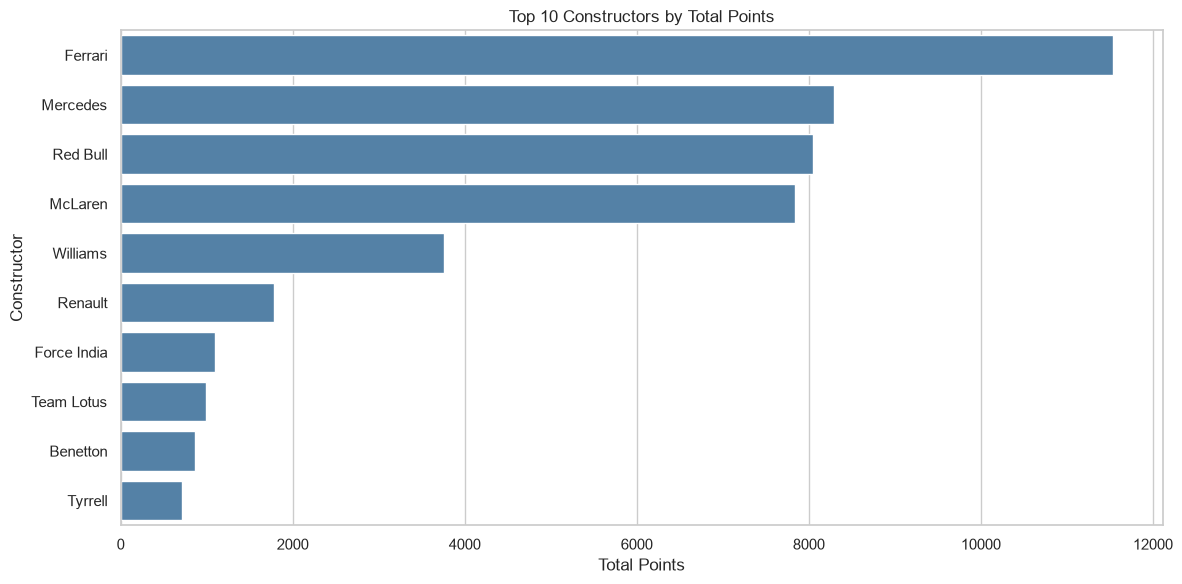

In [43]:
plt.figure(figsize=(12, 6))
sns.barplot(
    color="steelblue",
    data=top_constructors,
    x="total_points",
    y="constructor_name",
)

plt.title("Top 10 Constructors by Total Points")
plt.xlabel("Total Points")
plt.ylabel("Constructor")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "h2_top_constructors_total_points.png", dpi=300)
plt.show()

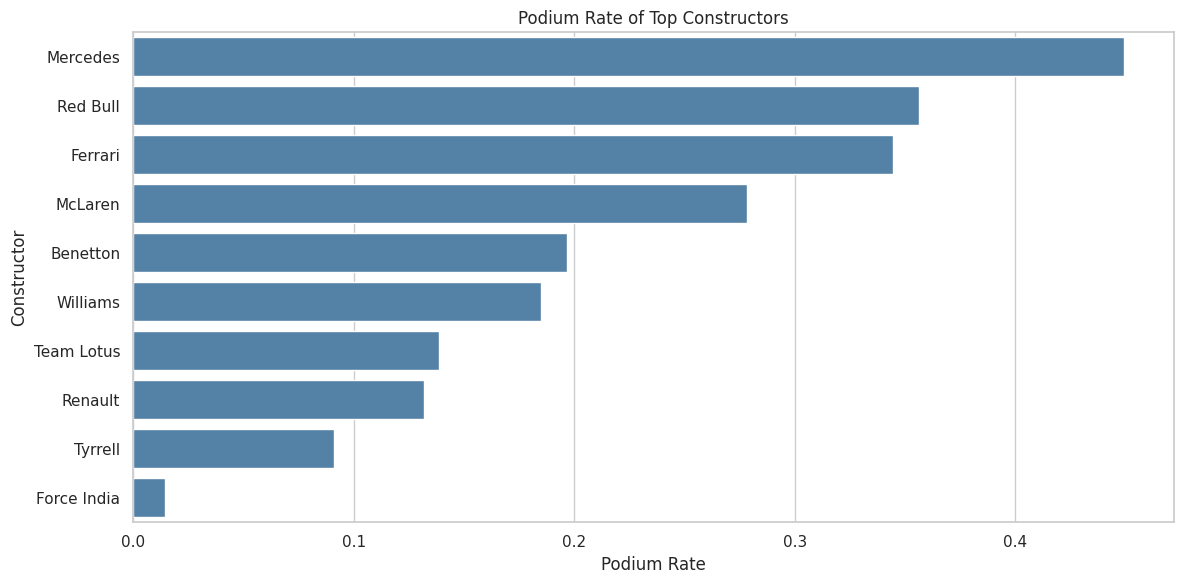

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(
    color="steelblue",
    data=top_constructors.sort_values("podium_rate", ascending=False),
    x="podium_rate",
    y="constructor_name",
)

plt.title("Podium Rate of Top Constructors")
plt.xlabel("Podium Rate")
plt.ylabel("Constructor")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "h2_top_constructors_podium_rate.png", dpi=300)
plt.show()

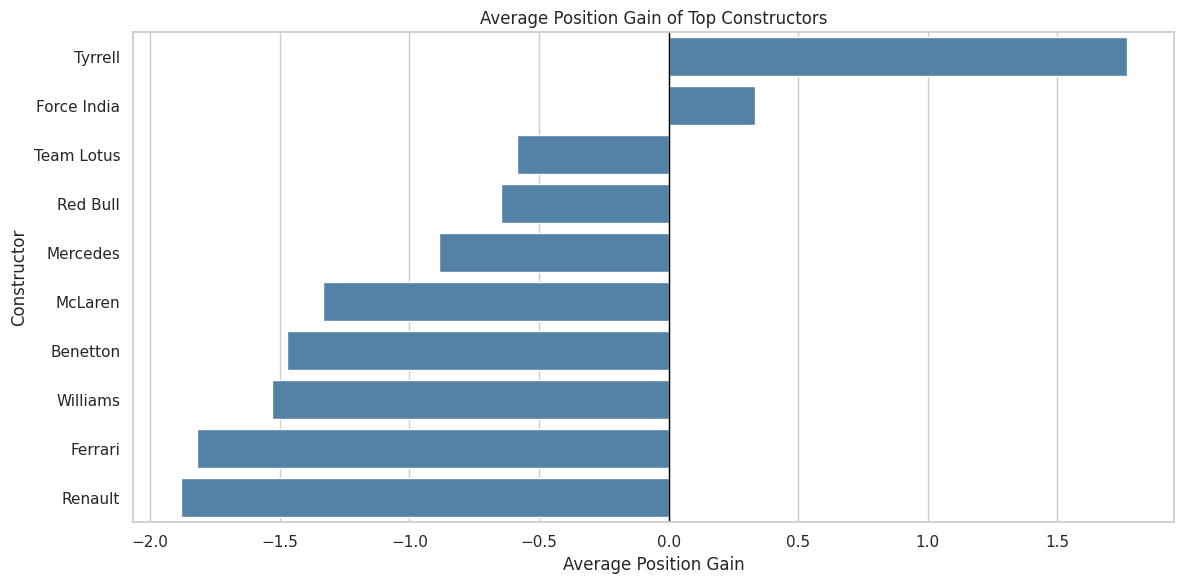

In [29]:
plt.figure(figsize=(12, 6))
sns.barplot(
    color="steelblue",
    data=top_constructors.sort_values("avg_position_gain", ascending=False),
    x="avg_position_gain",
    y="constructor_name",
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Average Position Gain of Top Constructors")
plt.xlabel("Average Position Gain")
plt.ylabel("Constructor")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "h2_top_constructors_position_gain.png", dpi=300)
plt.show()

The second hypothesis is supported by the data. The top constructors by total points also tend to have high average points and podium rates. However, they do not necessarily have the highest average position gain. This is reasonable because dominant teams often start near the front of the grid, which gives them fewer opportunities to gain many positions during a race.

### Hypothesis 3

**The share of classified finishes increased over time, suggesting improved reliability in modern Formula 1.**

A classified finish is defined as a result with status `Finished` or a status containing `Lap`, such as `+1 Lap` or `+2 Laps`.

In [47]:
reliability_df = main_df[
    main_df["status"].notna()
].copy()

finish_rate_by_era = (
    reliability_df
    .groupby("era")
    .agg(
        race_results=("resultId", "count"),
        classified_finishes=("is_classified_finish", "sum"),
        classified_finish_rate=("is_classified_finish", "mean"),
    )
    .reset_index()
)

finish_rate_by_era["era"] = pd.Categorical(
    finish_rate_by_era["era"],
    categories=era_order,
    ordered=True,
)

finish_rate_by_era = finish_rate_by_era.sort_values("era")

finish_rate_by_era

,era,race_results,classified_finishes,classified_finish_rate
0,1950-1979,7927,3723,0.469661
1,1980-1999,8753,3688,0.421341
2,2000-2013,5453,3925,0.719787
3,2014-2026,5193,4314,0.830734


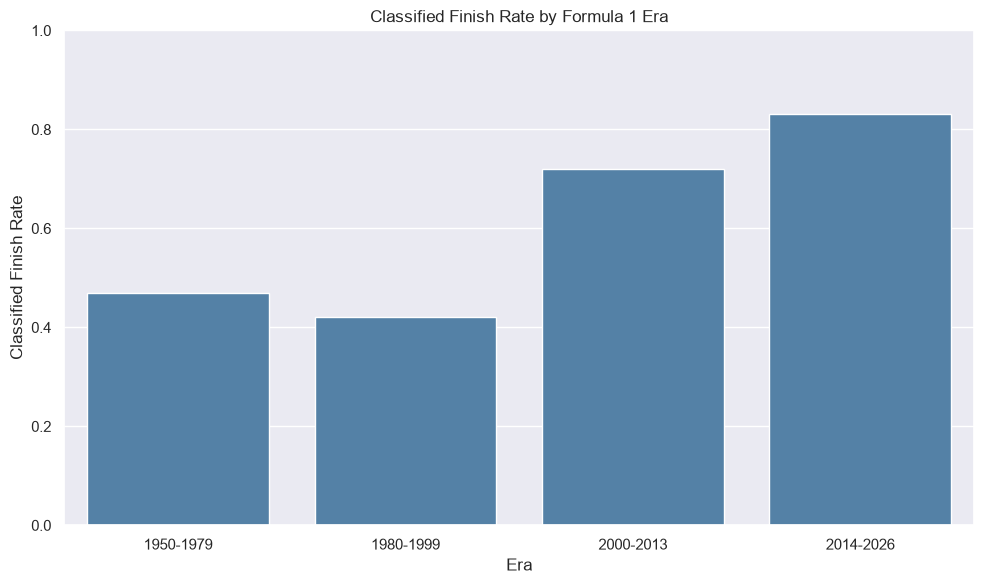

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(
    color="steelblue",
    data=finish_rate_by_era,
    x="era",
    y="classified_finish_rate",
)

plt.title("Classified Finish Rate by Formula 1 Era")
plt.xlabel("Era")
plt.ylabel("Classified Finish Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "h3_classified_finish_rate_by_era.png", dpi=300)
plt.show()

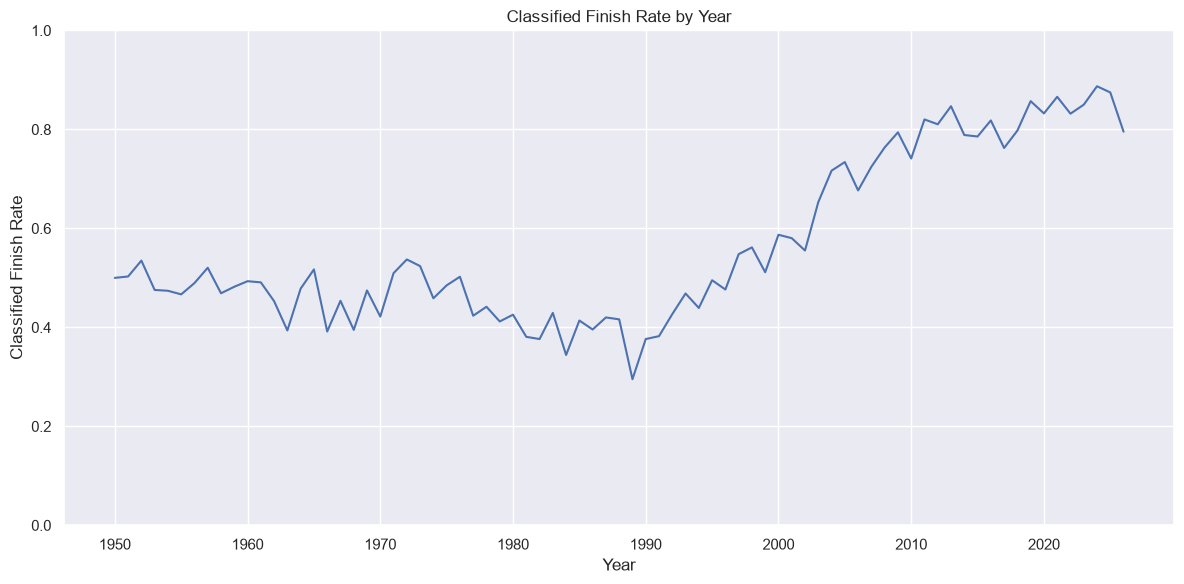

In [49]:
finish_rate_by_year = (
    reliability_df
    .groupby("year")
    .agg(
        race_results=("resultId", "count"),
        classified_finishes=("is_classified_finish", "sum"),
        classified_finish_rate=("is_classified_finish", "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=finish_rate_by_year,
    x="year",
    y="classified_finish_rate",
)

plt.title("Classified Finish Rate by Year")
plt.xlabel("Year")
plt.ylabel("Classified Finish Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "h3_classified_finish_rate_by_year.png", dpi=300)
plt.show()

The third hypothesis is supported by the data. The classified finish rate is much higher in modern Formula 1 eras than in earlier periods. The yearly trend also shows a clear increase over time, especially from the 2000s onward. This pattern is consistent with improved reliability in modern Formula 1, although the analysis does not directly identify the technical causes of this improvement.

## 12. Discussion and conclusion

This project analyzed Formula 1 race performance using a merged relational dataset. The analysis showed that starting grid position is an important factor in race outcomes, especially in modern eras. Constructor-level analysis showed that dominant teams have high points and podium rates, but their average position gain is not necessarily the highest. Finally, the reliability analysis showed that classified finish rates increased substantially over time.

Overall, the project demonstrates how race results, constructor performance, circuit context and historical era can be analyzed using Python, pandas and visualization libraries. The main limitation is that the analysis is descriptive and does not model all possible causal factors such as weather, strategy, safety cars or regulation changes.